# Imports and def

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
import colormaps as cmaps
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

In [26]:
def reg_map(
    ds_to_plt,
    dots,
    bounds=[20, -180, 30, -30],
    name="figure",
    color=cmaps.posneg_1,
    lcolor=["magenta", "cyan"],
    lev=np.arange(-1.5, 1.5, 0.15),
):
    fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    cdot, cdot_lon = cutil.add_cyclic_point(dots, dots.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2] + 1, 15)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

    # local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0, 0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())

    ds_plot = ax.contourf(
        clon,
        ds_to_plt.lat,
        cdat,
        levels=lev,
        # levels=40,
        transform=ccrs.PlateCarree(),
        cmap=color,
        extend="both",
    )

    dot_plot = ax.contourf(
        cdot_lon,
        dots.lat,
        cdot,
        transform=ccrs.PlateCarree(),
        linestyles="-",
        hatches=["..", ""],
        levels=[0, 0.05],
        colors="None",  # lcolor,
        alpha=0.1,
    )

    fig.canvas.mpl_connect("resize_event", resize_colobar)
    ax.add_feature(cf.LAND)
    ax.coastlines()
    plt.colorbar(ds_plot, cax=cbar_ax)
    resize_colobar(None)
    plt.savefig(name, dpi=300, bbox_inches="tight")
    plt.show()

# Import Data

In [3]:
CESM_PRECTAr = xr.open_zarr("/glade/work/acruz/CESM/PRECTAreg")
CESM_SSTAr = xr.open_zarr("/glade/work/acruz/CESM/SSTAreg")

# SST

In [4]:
CESM_SSTAr

<xarray.Dataset> Size: 177MB
Dimensions:              (member: 100, lat: 192, lon: 288)
Coordinates:
  * member               (member) int64 800B 0 1 2 3 4 5 6 ... 94 95 96 97 98 99
  * lat                  (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                  (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
Data variables:
    JJA_SSTA_CANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    JJA_SSTA_CANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
    JJA_SSTA_EANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    JJA_SSTA_EANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
    SON_SSTA_CANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    SON_SSTA_CANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
    SON_SSTA_EANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    SON_SSTA_EANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
Attributes:
    Description:  Linear regression results from CESM SST anomaalies between ...

In [5]:
# Mask Before ensemble mean
pvt = 0.5

JJAEANI_SSTA = CESM_SSTAr["JJA_SSTA_EANI_slope"].where(
    CESM_SSTAr["JJA_SSTA_EANI_pval"] <= pvt
)
JJACANI_SSTA = CESM_SSTAr["JJA_SSTA_CANI_slope"].where(
    CESM_SSTAr["JJA_SSTA_CANI_pval"] <= pvt
)
SONEANI_SSTA = CESM_SSTAr["SON_SSTA_EANI_slope"].where(
    CESM_SSTAr["SON_SSTA_EANI_pval"] <= pvt
)
SONCANI_SSTA = CESM_SSTAr["SON_SSTA_CANI_slope"].where(
    CESM_SSTAr["SON_SSTA_CANI_pval"] <= pvt
)

In [6]:
# ensemble mean
JJAEANI_SSTA_ensm = JJAEANI_SSTA.mean(dim="member")
JJACANI_SSTA_ensm = JJACANI_SSTA.mean(dim="member")
SONEANI_SSTA_ensm = SONEANI_SSTA.mean(dim="member")
SONCANI_SSTA_ensm = SONCANI_SSTA.mean(dim="member")

JJAEANI_SSTA_ensmp = CESM_SSTAr["JJA_SSTA_EANI_pval"].mean(dim="member")
JJACANI_SSTA_ensmp = CESM_SSTAr["JJA_SSTA_CANI_pval"].mean(dim="member")
SONEANI_SSTA_ensmp = CESM_SSTAr["SON_SSTA_EANI_pval"].mean(dim="member")
SONCANI_SSTA_ensmp = CESM_SSTAr["SON_SSTA_CANI_pval"].mean(dim="member")

In [7]:
CESM_SSTAr["JJA_SSTA_EANI_pval"]

<xarray.DataArray 'JJA_SSTA_EANI_pval' (member: 100, lat: 192, lon: 288)> Size: 22MB
dask.array<open_dataset-JJA_SSTA_EANI_pval, shape=(100, 192, 288), dtype=float32, chunksize=(25, 48, 144), chunktype=numpy.ndarray>
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8

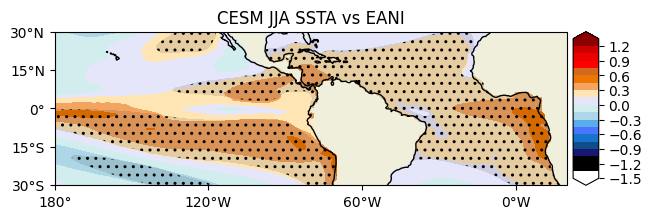

In [27]:
reg_map(JJAEANI_SSTA_ensm, JJAEANI_SSTA_ensmp, name="CESM JJA SSTA vs EANI")

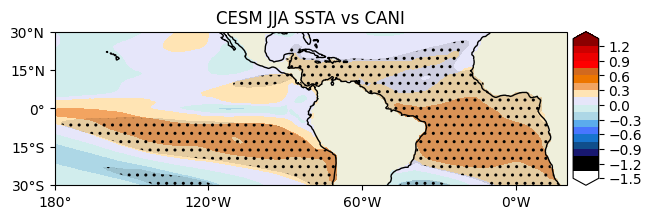

In [28]:
reg_map(JJACANI_SSTA_ensm, JJACANI_SSTA_ensmp, name="CESM JJA SSTA vs CANI")

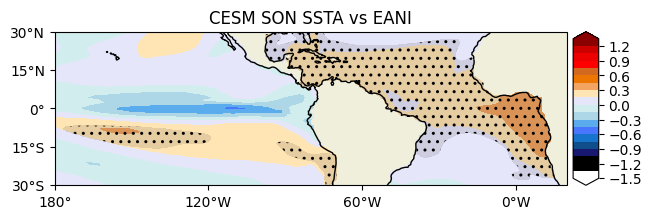

In [29]:
reg_map(SONEANI_SSTA_ensm, SONEANI_SSTA_ensmp, name="CESM SON SSTA vs EANI")

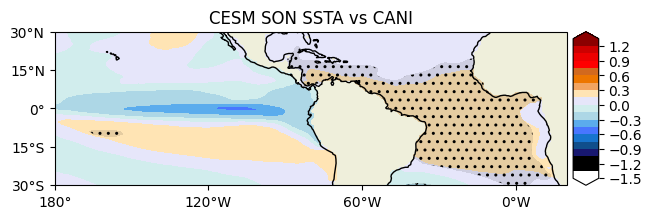

In [30]:
reg_map(SONCANI_SSTA_ensm, SONCANI_SSTA_ensmp, name="CESM SON SSTA vs CANI")

# PRECP

In [12]:
CESM_PRECTAr

<xarray.Dataset> Size: 177MB
Dimensions:                (member: 100, lat: 192, lon: 288)
Coordinates:
  * member                 (member) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
  * lat                    (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                    (lon) float64 2kB -180.0 -178.8 ... 177.5 178.8
Data variables:
    JJA_PRECTA_CANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    JJA_PRECTA_CANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
    JJA_PRECTA_EANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    JJA_PRECTA_EANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
    SON_PRECTA_CANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    SON_PRECTA_CANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
    SON_PRECTA_EANI_pval   (member, lat, lon) float32 22MB dask.array<chunksize=(25, 48, 144), meta=np.ndarray>
    SON_PRECTA_EANI_slope  (member, lat, lon) float32 22MB dask.array<chunksize=(100, 192, 288), meta=np.ndarray>
Attributes:
    Description:  Linear regression results from CESM Total Precipitation ano...

In [18]:
# Mask Before ensemble mean
JJAEANI_PRECTA = CESM_PRECTAr["JJA_PRECTA_EANI_slope"].where(
    CESM_PRECTAr["JJA_PRECTA_EANI_pval"] <= pvt
)
JJACANI_PRECTA = CESM_PRECTAr["JJA_PRECTA_CANI_slope"].where(
    CESM_PRECTAr["JJA_PRECTA_CANI_pval"] <= pvt
)
SONEANI_PRECTA = CESM_PRECTAr["SON_PRECTA_EANI_slope"].where(
    CESM_PRECTAr["SON_PRECTA_EANI_pval"] <= pvt
)
SONCANI_PRECTA = CESM_PRECTAr["SON_PRECTA_CANI_slope"].where(
    CESM_PRECTAr["SON_PRECTA_CANI_pval"] <= pvt
)

In [19]:
# ensemble mean
JJAEANI_PRECTA_ensm = JJAEANI_PRECTA.mean(dim="member")
JJACANI_PRECTA_ensm = JJACANI_PRECTA.mean(dim="member")
SONEANI_PRECTA_ensm = SONEANI_PRECTA.mean(dim="member")
SONCANI_PRECTA_ensm = SONCANI_PRECTA.mean(dim="member")

JJAEANI_PRECTA_ensmp = CESM_PRECTAr["JJA_PRECTA_EANI_pval"].mean(dim="member")
JJACANI_PRECTA_ensmp = CESM_PRECTAr["JJA_PRECTA_CANI_pval"].mean(dim="member")
SONEANI_PRECTA_ensmp = CESM_PRECTAr["SON_PRECTA_EANI_pval"].mean(dim="member")
SONCANI_PRECTA_ensmp = CESM_PRECTAr["SON_PRECTA_CANI_pval"].mean(dim="member")

In [40]:
JJAEANI_PRECTA_ensmc = JJAEANI_PRECTA_ensm * (1000 * (24 * 60 * 60))
JJACANI_PRECTA_ensmc = JJACANI_PRECTA_ensm * (1000 * (24 * 60 * 60))
SONEANI_PRECTA_ensmc = SONEANI_PRECTA_ensm * (1000 * (24 * 60 * 60))
SONCANI_PRECTA_ensmc = SONCANI_PRECTA_ensm * (1000 * (24 * 60 * 60))

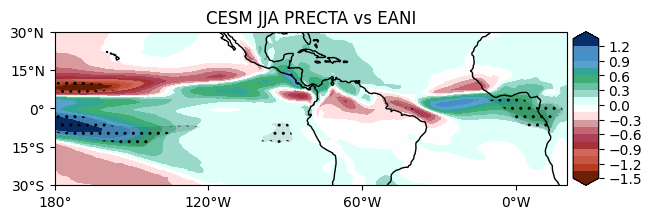

In [43]:
reg_map(
    JJAEANI_PRECTA_ensmc,
    JJAEANI_PRECTA_ensmp,
    name="CESM JJA PRECTA vs EANI",
    color=cmaps.precip4_diff_19lev,
)

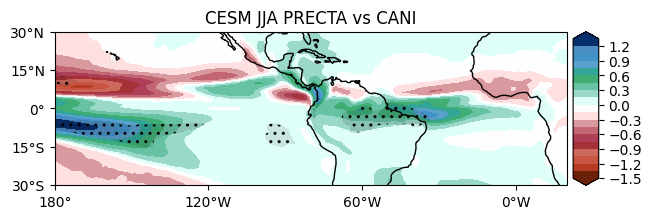

In [44]:
reg_map(
    JJACANI_PRECTA_ensmc,
    JJACANI_PRECTA_ensmp,
    name="CESM JJA PRECTA vs CANI",
    color=cmaps.precip4_diff_19lev,
)

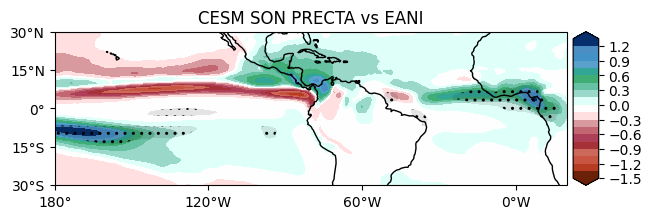

In [45]:
reg_map(
    SONEANI_PRECTA_ensmc,
    SONEANI_PRECTA_ensmp,
    name="CESM SON PRECTA vs EANI",
    color=cmaps.precip4_diff_19lev,
)

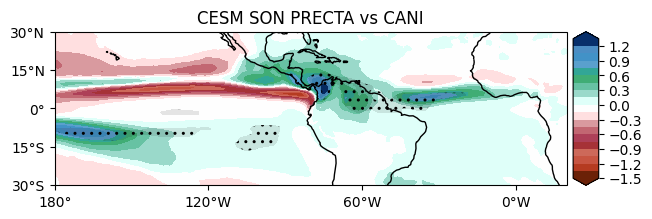

In [46]:
reg_map(
    SONCANI_PRECTA_ensmc,
    SONCANI_PRECTA_ensmp,
    name="CESM SON PRECTA vs CANI",
    color=cmaps.precip4_diff_19lev,
)